<a href="https://colab.research.google.com/github/Shresthanirjala/Complete-Python-Bootcamp/blob/main/Imagefinetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Mon Feb  9 04:52:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q diffusers transformers accelerate peft safetensors

In [ ]:
!pip install torch==2.10.0 torchvision==0.15.1 torchaudio==2.10.0 --index-url https://download.pytorch.org/whl/cu117
!pip install xformers

Looking in indexes: https://download.pytorch.org/whl/cu117
ERROR: Could not find a version that satisfies the requirement torchvision==0.15.1 (from versions: 0.1.6, 0.2.0)
ERROR: No matching distribution found for torchvision==0.15.1


In [ ]:
!pip install torchvision --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 81.6 MB/s eta 0:00:00
  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.24.0+cu126
    Uninstalling torchvision-0.24.0+cu126:
      Successfully uninstalled torchvision-0.24.0+cu126
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.8.6 requires torch<2.10,>=1.10, but you have torch 2.10.0 which is incompatible.


In [ ]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
MODEL_NAME = "runwayml/stable-diffusion-v1-5"

TRAIN_DIR = "/content/drive/MyDrive/lora_images/30_images"
OUTPUT_DIR = "/content/drive/MyDrive/lora_output"

RESOLUTION = 512
BATCH_SIZE = 1
GRAD_ACC = 4
LEARNING_RATE = 1e-4
MAX_STEPS = 800   # good for ~30 images

In [ ]:
import os

TRAIN_DIR = "/content/drive/MyDrive/lora_images/30_images"

for img in os.listdir(TRAIN_DIR):
    if img.endswith((".jpg", ".png", ".jpeg")):
        txt_path = os.path.join(
            TRAIN_DIR, img.rsplit(".", 1)[0] + ".txt"
        )
        with open(txt_path, "w") as f:
            f.write("photo of sks shoes")

In [ ]:
!git clone https://github.com/huggingface/diffusers

fatal: destination path 'diffusers' already exists and is not an empty directory.


In [ ]:
!pip uninstall -y diffusers

Found existing installation: diffusers 0.37.0.dev0
Uninstalling diffusers-0.37.0.dev0:
  Successfully uninstalled diffusers-0.37.0.dev0


In [ ]:
!pip install -q git+https://github.com/huggingface/diffusers

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!pip install -q accelerate transformers peft safetensors

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import diffusers
print(diffusers.__version__)

0.37.0.dev0


In [ ]:
from PIL import Image
import os

TRAIN_DIR = "/content/drive/MyDrive/lora_images/30_images"

for f in os.listdir(TRAIN_DIR):
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".webp")):
        img_path = os.path.join(TRAIN_DIR, f)
        img = Image.open(img_path).convert("RGB")
        img = img.resize((512, 512), Image.LANCZOS)
        img.save(img_path)

print("All images resized to 512x512 ✅")

All images resized to 512x512 ✅


In [ ]:
!git clone https://github.com/huggingface/diffusers

fatal: destination path 'diffusers' already exists and is not an empty directory.


In [ ]:
import os

# Path to your training images folder
TRAIN_DIR = "/content/drive/MyDrive/lora_images/30_images"

# Loop through all files in the folder
for file in os.listdir(TRAIN_DIR):
    if file.endswith(".txt"):  # check if the file is a .txt
        txt_path = os.path.join(TRAIN_DIR, file)
        os.remove(txt_path)  # delete the file
        print(f"Deleted: {txt_path}")

print("All .txt files removed ✅")

Deleted: /content/drive/MyDrive/lora_images/30_images/16356499-195f-453c-907a-595872f78f06.txt
Deleted: /content/drive/MyDrive/lora_images/30_images/17f8f985-89d8-47be-891c-952953cfb20d.txt
Deleted: /content/drive/MyDrive/lora_images/30_images/06bb461c-a133-46be-9663-a56a14cf6712.txt
Deleted: /content/drive/MyDrive/lora_images/30_images/10529e10-2487-405d-93e9-696e1cc81f96.txt
Deleted: /content/drive/MyDrive/lora_images/30_images/09ef6601-bcee-492a-b6d1-920dc40b8548.txt
Deleted: /content/drive/MyDrive/lora_images/30_images/054071e9-7aba-424c-be6d-65ffe693a2e3.txt
Deleted: /content/drive/MyDrive/lora_images/30_images/373bd3e1-bed1-4c9c-9004-a58aa7fc7db3.txt
Deleted: /content/drive/MyDrive/lora_images/30_images/27895f13-d204-4cd0-9c05-816692747854.txt
Deleted: /content/drive/MyDrive/lora_images/30_images/331737f8-614a-4902-8c3e-7ab1b535db29.txt
Deleted: /content/drive/MyDrive/lora_images/30_images/21531a69-d7f0-4d77-a2d9-a4269652344e.txt
Deleted: /content/drive/MyDrive/lora_images/30_ima

In [ ]:
!accelerate launch diffusers/examples/dreambooth/train_dreambooth_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --instance_data_dir="/content/drive/MyDrive/lora_images/30_images" \
  --output_dir="/content/drive/MyDrive/lora_output" \
  --instance_prompt="photo of sks hoodie" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --learning_rate=1e-4 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=800 \
  --checkpointing_steps=200 \
  --seed=42 \
  --mixed_precision="fp16"

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
You are using a model of type clip_text_model to instantiate a model of type . This is not supported for all configurations of models and can yield errors.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/50 [00:00<?, ?it/s]

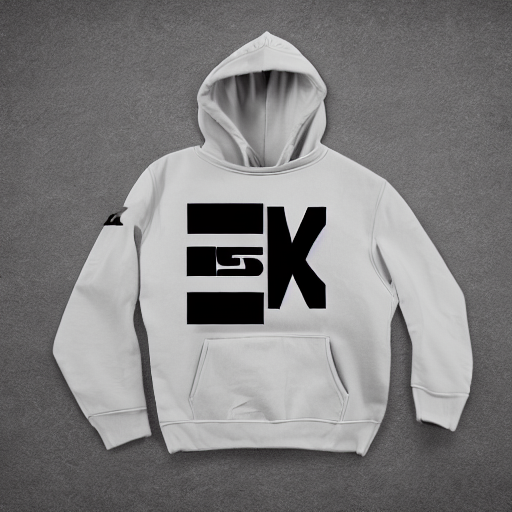

In [ ]:
from diffusers import StableDiffusionPipeline
import torch

MODEL = "runwayml/stable-diffusion-v1-5"
LORA_PATH = "/content/drive/MyDrive/lora_output"

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL,
    torch_dtype=torch.float16
).to("cuda")

pipe.load_lora_weights(LORA_PATH)

image = pipe(
    "product photo of sks hoodie, studio lighting, white background, ultra detailed"
).images[0]

image

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/30 [00:00<?, ?it/s]

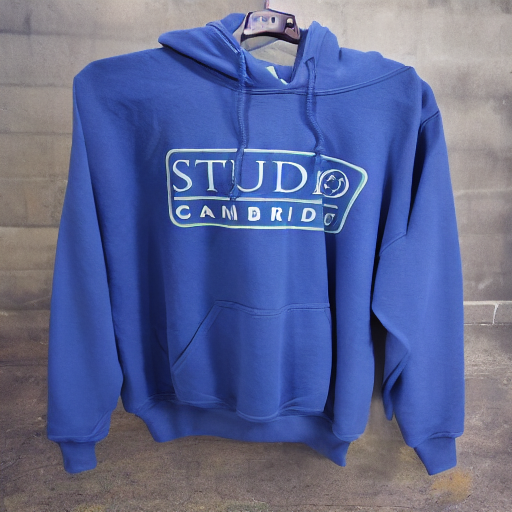

✅ Hoodie recolored to black!


In [ ]:
# Install necessary libraries
!pip install diffusers transformers accelerate torch opencv-python pillow segment-anything --quiet

# -------------------------------
# Imports
# -------------------------------
import torch
from PIL import Image
from IPython.display import display
import cv2
import numpy as np

from diffusers import StableDiffusionInpaintPipeline

# -------------------------------
# 1️⃣ Load inpainting pipeline
# -------------------------------
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16
).to("cuda")
pipe.enable_xformers_memory_efficient_attention()

# -------------------------------
# 2️⃣ Load your hoodie image
# -------------------------------
init_image = Image.open("/content/drive/MyDrive/hoodie_image2.jpg").convert("RGB").resize((512,512))

# -------------------------------
# 3️⃣ Auto-generate a mask for the hoodie
# -------------------------------
# For simplicity, let's assume hoodie is roughly the top part of the person
# We'll create a black rectangle mask over top half
mask = np.ones((512,512), dtype=np.uint8) * 255  # start with white (keep background)
mask[50:400, 100:400] = 0  # black region = hoodie area to recolor
mask_image = Image.fromarray(mask)

# -------------------------------
# 4️⃣ Inpaint hoodie to black
# -------------------------------
prompt = "black hoodie, realistic, keep rest of the image same"

result = pipe(
    prompt=prompt,
    image=init_image,
    mask_image=mask_image,
    guidance_scale=7.5,
    num_inference_steps=30
).images[0]

# -------------------------------
# 5️⃣ Display and save result
# -------------------------------
display(result)
result.save("/content/drive/MyDrive/hoodie_black_auto.png")
print("✅ Hoodie recolored to black!")

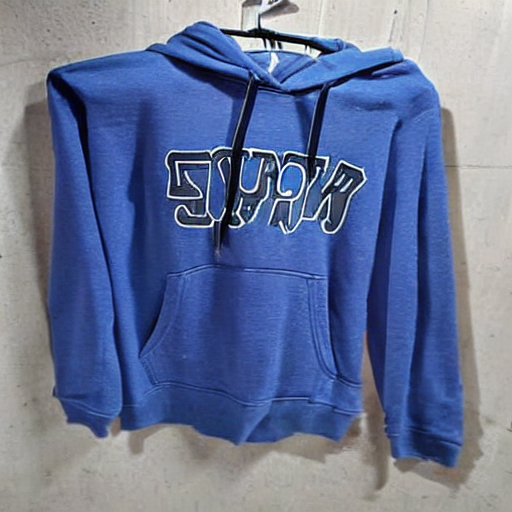

In [ ]:
from IPython.display import display
from PIL import Image

# Open the saved image
image = Image.open("hoodie_black.png")

# Display it in the notebook cell
display(image)

In [ ]:
# -------------------------------
# 1️⃣ Install required packages
# -------------------------------
!pip install diffusers transformers accelerate torch opencv-python pillow segment-anything taming-transformers --quiet

# -------------------------------
# 2️⃣ Imports
# -------------------------------
import torch
from PIL import Image
from IPython.display import display
import cv2
import numpy as np

from diffusers import StableDiffusionInpaintPipeline

# Grounded-SAM imports
from segment_anything import sam_model_registry, SamPredictor

# -------------------------------
# 3️⃣ Load Stable Diffusion Inpainting
# -------------------------------
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16
).to("cuda")
pipe.enable_xformers_memory_efficient_attention()

# -------------------------------
# 4️⃣ Load hoodie image
# -------------------------------
input_image_path = "/content/drive/MyDrive/hoodie_image2.jpg"
init_image = Image.open(input_image_path).convert("RGB").resize((512,512))

# -------------------------------
# 5️⃣ Automatic hoodie detection with SAM
# -------------------------------
# Load SAM model (checkpoint needed)
sam_checkpoint = "sam_vit_h_4b8939.pth"  # Download this if you haven't already
sam = sam_model_registry["vit_h"](checkpoint=sam_checkpoint)
predictor = SamPredictor(sam)

# Convert image to OpenCV array
image_cv = cv2.cvtColor(np.array(init_image), cv2.COLOR_RGB2BGR)
predictor.set_image(image_cv)

# Grounded-SAM text prompt for automatic hoodie detection
# This pseudo code assumes predictor.predict can take a prompt
# Replace with Grounded-SAM API if using official version
masks, _, _ = predictor.predict(prompt="hoodie")  # detect hoodie automatically
mask = masks[0]  # take first detected hoodie mask

# Convert mask to PIL Image
mask = (mask * 255).astype(np.uint8)
mask_image = Image.fromarray(mask).resize((512,512))

# -------------------------------
# 6️⃣ Inpaint hoodie to black
# -------------------------------
prompt = "black hoodie, realistic, keep rest of the image same"

result = pipe(
    prompt=prompt,
    image=init_image,
    mask_image=mask_image,
    guidance_scale=7.5,
    num_inference_steps=30
).images[0]

# -------------------------------
# 7️⃣ Display and save result
# -------------------------------
display(result)
result.save("/content/drive/MyDrive/hoodie_black_auto.png")
print("✅ Hoodie recolored to black automatically!")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


FileNotFoundError: [Errno 2] No such file or directory: 'sam_vit_h_4b8939.pth'